# Hash-Ribbons — a quantitative teardown 🔬
### The crossover-detection filter · Welch/placebo forward-return tests at four horizons · a 180-day timer vs buy-and-hold · a 20-seed synthetic null

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Beats_random_buy_dates%3F: Busted](https://img.shields.io/badge/Beats_random_buy_dates%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — a 30d/60d hashrate-SMA crossover marks the end of miner capitulation and precedes above-average BTC returns — is tested as a **discrete event study**, not a continuous exposure rule (that question already belongs to sibling study 292-bitcoin-hashrate). The headline constraint, said loudly and often: **n = 4**.

> ⚠️ **Data note.** Hardcoded month-end hashrate table (identical to 292-bitcoin-hashrate), linearly interpolated to daily — smooths intra-month noise, a named limitation. BTC-USD daily close, yfinance, 2014-09-17 → 2026-06-30 (fingerprint `9529d5277775`). No survivorship concept on the hashrate series itself (a single network's own metric); BTC-USD's single-survivor character is named on the Tradability axis. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from hash_ribbons import data, strategy as st

HR = data.hashrate_daily()
HAVE_REAL = data.have_real()
if HAVE_REAL:
    BTC = data.load_btc()
    SIG = st.capitulation_signals(HR)
else:
    BTC = SIG = None
print("real cache present:", HAVE_REAL, "| hashrate path points:", len(HR),
      "| signals:", (0 if SIG is None else len(SIG)))

# frozen headline numbers (mirror of docs/results.md)
R = {'hr_lo': '2014-01-31', 'hr_hi': '2026-05-31', 'hr_n': 4504, 'btc_lo': '2014-09-17', 'btc_hi': '2026-06-30', 'btc_n': 4305, 'fp_btc': '9529d5277775', 'n_signals': 4, 'signals': [{'date': '2019-02-12', 'days': 105, 'window': '2018-10-30 -> 2019-02-11', 'decline': -19.7}, {'date': '2020-04-30', 'days': 30, 'window': '2020-03-31 -> 2020-04-29', 'decline': -8.1}, {'date': '2020-06-30', 'days': 31, 'window': '2020-05-30 -> 2020-06-29', 'decline': -8.1}, {'date': '2021-08-15', 'days': 89, 'window': '2021-05-18 -> 2021-08-14', 'decline': -43.9}], 'fwd': {30: (10.3, 9.7, 5.9, 22.93, 0.97, 0.3076), 90: (49.1, 32.6, 21.06, 53.69, 1.27, 0.1358), 180: (112.7, 122.6, 51.46, 104.23, 1.15, 0.1278), 365: (246.1, 233.0, 146.83, 268.65, 0.78, 0.1815)}, 'placebo_draws': 20000, 'n_entries': 3, 'years': 7.4, 'strat_total': 769.8, 'strat_cagr': 34.07, 'strat_sharpe': 1.1, 'exposure': 22.4, 'bh_total': 1502.8, 'bh_cagr': 45.65, 'bh_sharpe': 0.92, 'syn_null_mean': -0.27, 'syn_null_sd': 1.29, 'syn_null_fire': 2, 'syn_planted_t': 4.03}


real cache present: True | hashrate path points: 4504 | signals: 4


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | best Welch **t = 1.27** (90d), best placebo **p = 0.128** (180d), n = 4 |
| **Tradability** | `FRAGILE` | timer Sharpe **1.10** vs B&H **0.92**, but total return **+770%** vs **+1503%** on 3 holding episodes |
| **Beats random dates?** | `BUSTED` | placebo *p* never below 0.128 at any of the 4 horizons |

> 💡 In plain words: the pattern is directionally consistent everywhere and certified nowhere — exactly what four data points should produce, whether or not there's a real effect underneath.

## 1 · The claim, steelmanned

Let $S = \{t_1, \dots, t_n\}$ be the set of Hash-Ribbons buy-signal dates and $r_{t,h}$ the $h$-day forward log-to-simple BTC return from day $t$. The claim:

- **H₁ (predictive).** $E[r_{t,h} \mid t \in S] > E[r_{t,h}]$ (the unconditional mean) at economically meaningful horizons.
- **H₂ (tradable).** A mechanical timer built on $S$ beats continuous buy-and-hold net of costs.

With $n = 4$, this is fundamentally an **underpowered** test — a single additional or missing historical episode would materially move every statistic below. We report the numbers honestly and let the sample size speak for itself rather than dressing up a 4-point estimate as a certified finding.

## 2 · So what? — inference design

Because $n$ is tiny and the events are not independent (two of the four signals sit two months apart in the same 2020 recovery), a Welch *t* against the unconditional distribution is reported but is explicitly **not** the primary arbiter — it is included because it's the desk's standard statistic, with a loud caveat that it is barely informative at this sample size. The **less parametric-dependent** check is a random-date placebo: draw $n$ random calendar dates (no replacement), repeat 20,000 times (20 seeds × 1,000 draws), and ask how often a random draw's mean forward return matches or beats the observed signal mean. That test only assumes we can resample dates fairly — it doesn't lean on small-sample normal-theory asymptotics the way a *t*-test does.

## 3 · How we'd know — the protocol

- **Hashrate path.** 4,504 daily points 2014-01-31 → 2026-05-31, linear interpolation of the hardcoded month-end table.
- **Signal filter.** SMA(30) crosses back above SMA(60), kept only if SMA(30) sat below SMA(60) for ≥21 days **and** hashrate itself fell ≥8% peak-to-trough during that stretch.
- **Tape.** BTC-USD daily close 2014-09-17 → 2026-06-30 (4,305 rows). As-of 2026-06-30 (last complete month).
- **Headline.** Forward returns at 30/90/180/365 days; Welch *t* + 20-seed × 1,000-draw random-date placebo, per horizon.
- **Execution.** Signal known at the crossover day's close; enter BTC at the **next** trading day's close (one-day lag, documented); 180-day fixed hold (a modeling choice, not folklore — Hash Ribbons has no native sell rule); 10 bps one-way × NAV × 2 legs per episode.
- **Control.** Synthetic BTC-like world, 6 planted signal windows, tunable post-signal drift; the null must not fire across 20 seeds.

## 4 · The teardown

### 4a · Signal detection — from 10 raw crossovers to 4 genuine capitulations

The raw SMA(30)/SMA(60) crossover fires 10 times on this tape; most are single-digit-percent wobbles. The magnitude filter (≥21 days below, ≥8% peak-to-trough decline) keeps the four unmistakable capitulations.

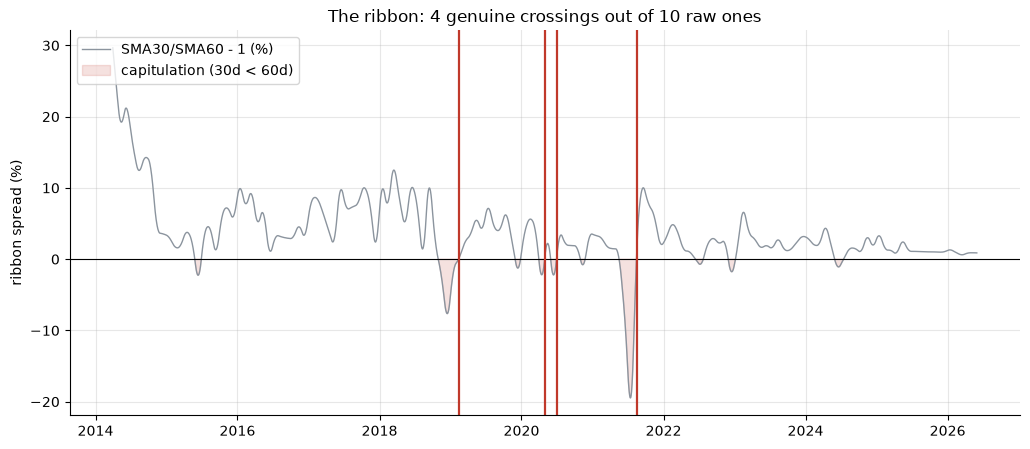

signal_date  capitulation_days  decline_pct
 2019-02-12                105   -19.709413
 2020-04-30                 30    -8.077994
 2020-06-30                 31    -8.077994
 2021-08-15                 89   -43.919598


In [2]:
if HAVE_REAL:
    sig = SIG
else:
    sig = pd.DataFrame(R['signals'])
    sig = sig.rename(columns={'date': 'signal_date', 'days': 'capitulation_days',
                              'decline': 'decline_pct'})
    sig['signal_date'] = pd.to_datetime(sig['signal_date'])
fig, ax = plt.subplots(figsize=(10.4, 4.6))
ratio = (HR.rolling(30).mean() / HR.rolling(60).mean() - 1) * 100
ax.plot(ratio.index, ratio.values, color=GREY, lw=1.0, label='SMA30/SMA60 - 1 (%)')
ax.axhline(0, c='k', lw=.8)
ax.fill_between(ratio.index, 0, ratio.values, where=(ratio.values < 0),
                color=RED, alpha=.15, label='capitulation (30d < 60d)')
for _, row in sig.iterrows():
    ax.axvline(row['signal_date'], color=RED, lw=1.6)
ax.set_ylabel('ribbon spread (%)'); ax.set_title('The ribbon: 4 genuine crossings out of 10 raw ones')
ax.legend(loc='upper left'); plt.tight_layout(); plt.show()
print(sig[['signal_date','capitulation_days','decline_pct']].to_string(index=False))

> 💡 In plain words: the filter isn't arbitrary noise-removal — it separates two unmistakably large events (−19.7% in 2019, −43.9% in 2021) and two medium ones (both −8.1%, the COVID/halving 2020 pair) from six much smaller wobbles the original Hash Ribbons concept was never meant to flag.

### 4b · Forward returns — Welch *t* and the random-date placebo

Per horizon: signal-conditional mean vs the unconditional distribution, Welch *t* (n≈4 — a formality, not a certificate), and the 20,000-draw placebo *p*.

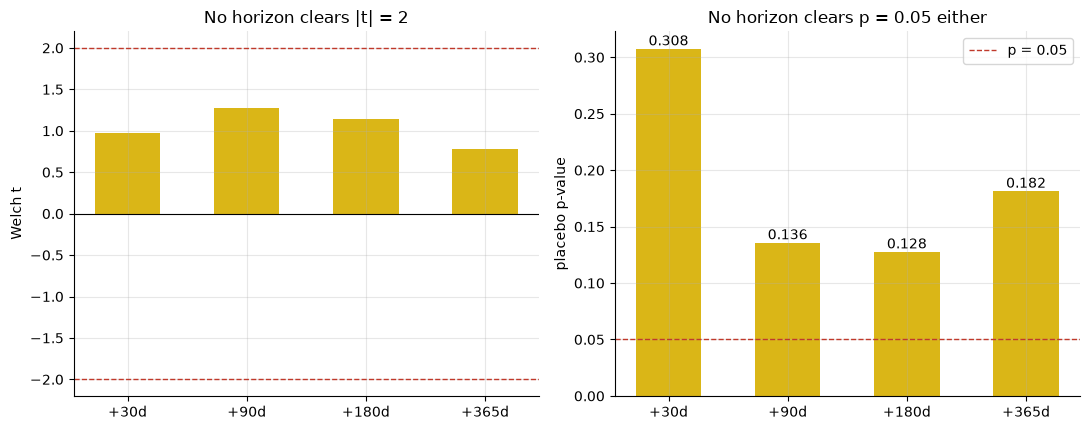

+30d: Welch t = +0.97  placebo p = 0.3076
+90d: Welch t = +1.27  placebo p = 0.1358
+180d: Welch t = +1.15  placebo p = 0.1278
+365d: Welch t = +0.78  placebo p = 0.1815


In [3]:
if HAVE_REAL:
    fr = st.forward_return_stats(BTC, SIG['signal_date'])
    hz = list(fr.index)
    sig_m = list(fr['signal_mean_pct']); unc_m = list(fr['uncond_mean_pct'])
    ts = list(fr['welch_t']); ps = list(fr['placebo_p'])
else:
    hz = [30, 90, 180, 365]
    sig_m = [R['fwd'][h][0] for h in hz]; unc_m = [R['fwd'][h][2] for h in hz]
    ts = [R['fwd'][h][4] for h in hz]; ps = [R['fwd'][h][5] for h in hz]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.4))
x = np.arange(len(hz))
a1.bar(x, ts, color=[RED if abs(t) >= 2 else AMBER for t in ts], width=.55)
a1.axhline(2, ls='--', c=RED, lw=1); a1.axhline(-2, ls='--', c=RED, lw=1); a1.axhline(0, c='k', lw=.8)
a1.set_xticks(x); a1.set_xticklabels([f'+{h}d' for h in hz]); a1.set_ylabel('Welch t')
a1.set_title('No horizon clears |t| = 2')
a2.bar(x, ps, color=AMBER, width=.55)
a2.axhline(0.05, ls='--', c=RED, lw=1, label='p = 0.05')
for i, v in enumerate(ps): a2.annotate(f'{v:.3f}', (x[i], v), ha='center', va='bottom')
a2.set_xticks(x); a2.set_xticklabels([f'+{h}d' for h in hz]); a2.set_ylabel('placebo p-value')
a2.set_title('No horizon clears p = 0.05 either'); a2.legend()
plt.tight_layout(); plt.show()
for h, t, p in zip(hz, ts, ps): print(f'+{h}d: Welch t = {t:+.2f}  placebo p = {p:.4f}')

> 💡 In plain words: the best Welch *t* is **1.27** (90 days) — positive, but a third of the way to the bar. The best placebo is **p = 0.128** (180 days) — meaning a random 4-date draw does as well or better roughly **1 time in 8**. Both tests agree: directionally consistent, nowhere near certified.

### 4c · The timer backtest — a real Sharpe trade-off, not a free lunch

180-day fixed hold after each signal (one-day entry lag), cash otherwise, 10 bps one-way × 2 legs per episode, compared to continuous buy-and-hold over the same [first signal → tape end] window.

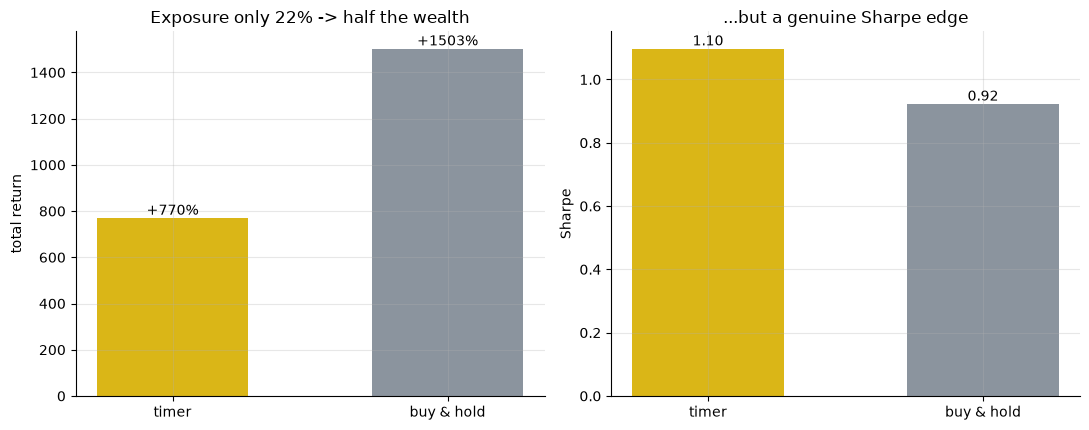

3 holding episodes, exposure 22.4%: total +769.8% vs +1502.8%; Sharpe 1.10 vs 0.92


In [4]:
if HAVE_REAL:
    tb = st.timer_backtest(BTC, SIG['signal_date'], hold_days=180, cost_bps=10.0)
else:
    tb = dict(strat_total_pct=R['strat_total'], bh_total_pct=R['bh_total'],
              strat_sharpe=R['strat_sharpe'], bh_sharpe=R['bh_sharpe'],
              exposure_pct=R['exposure'], n_entries=R['n_entries'])
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.4))
a1.bar(['timer', 'buy & hold'], [tb['strat_total_pct'], tb['bh_total_pct']],
       color=[AMBER, GREY], width=.55)
for i, v in enumerate([tb['strat_total_pct'], tb['bh_total_pct']]):
    a1.annotate(f'{v:+.0f}%', (i, v), ha='center', va='bottom')
a1.set_ylabel('total return'); a1.set_title(f"Exposure only {tb['exposure_pct']:.0f}% -> half the wealth")
a2.bar(['timer', 'buy & hold'], [tb['strat_sharpe'], tb['bh_sharpe']], color=[AMBER, GREY], width=.55)
for i, v in enumerate([tb['strat_sharpe'], tb['bh_sharpe']]): a2.annotate(f'{v:.2f}', (i, v), ha='center', va='bottom')
a2.set_ylabel('Sharpe'); a2.set_title('...but a genuine Sharpe edge')
plt.tight_layout(); plt.show()
print(f"{tb['n_entries']} holding episodes, exposure {tb['exposure_pct']:.1f}%: "
      f"total {tb['strat_total_pct']:+.1f}% vs {tb['bh_total_pct']:+.1f}%; "
      f"Sharpe {tb['strat_sharpe']:.2f} vs {tb['bh_sharpe']:.2f}")

> 💡 In plain words: sitting out 78% of the tape and still landing a better Sharpe ratio (1.10 vs 0.92) means the timer really is picking better-than-average windows — that's consistent with H₁'s direction. But Bitcoin's dominant feature over this sample is a near-monotone uptrend, and any rule that spends most of its time in cash gives up the compounding that comes with simply staying invested — the realized total-return gap (+770% vs +1503%) is the price of that caution, built on just **3 distinct trades**.

### 4d · Faithful-engine & power control — we know the truth here

Synthetic BTC-like daily-return world, 6 evenly-spaced planted signal windows, TUNABLE post-signal drift. The null (effect = 0) is checked over **20 seeds** — never a single stream, and deliberately at the same tiny event count as the real tape, so its false-positive rate is directly comparable to what we should expect from n≈4-6.

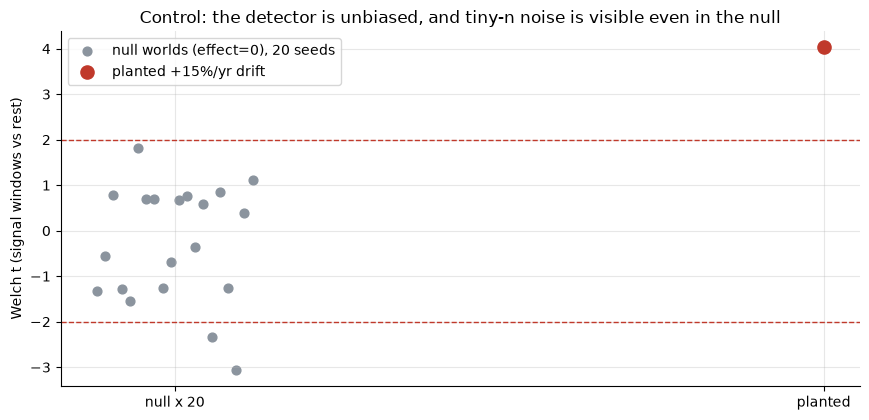

null: mean t = -0.27 (sd 1.29), |t|>=2 in 2/20 seeds  |  planted t = +4.03


In [5]:
null_ts = []
for s in range(20):
    r, sidx = data.synthetic_world(effect=0.0, seed=663 + s)
    null_ts.append(st.synthetic_detect(r, sidx))
null_ts = np.asarray(null_ts)
r, sidx = data.synthetic_world(effect=15.0, seed=663)
planted_t = st.synthetic_detect(r, sidx)
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.zeros(20) + np.linspace(-.12, .12, 20), null_ts, color=GREY, s=40,
           label='null worlds (effect=0), 20 seeds')
ax.scatter([1], [planted_t], color=RED, s=90, zorder=5, label='planted +15%/yr drift')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['null x 20', 'planted'])
ax.set_ylabel('Welch t (signal windows vs rest)')
ax.set_title('Control: the detector is unbiased, and tiny-n noise is visible even in the null')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_ts) >= 2).sum()}/20 seeds  |  planted t = {planted_t:+.2f}')

> 💡 In plain words: the detector recovers a real planted effect cleanly (t = 4.03). But look at the null column: even with **no** true effect, 2/20 seeds cross |t| = 2 purely by chance, because with only ~6 events per world, sampling noise alone can occasionally look "significant." That's the exact caution this study applies to the real tape's own Welch *t*'s of 0.78-1.27 — they are unremarkable, and even if one of them had crossed 2, a tiny-n null can do that on its own roughly 10% of the time. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `WEAK`** — every horizon (30/90/180/365 days) beats the unconditional mean forward BTC return, but the best Welch *t* is **1.27** (90d) and the best placebo is **p = 0.128** (180d) — neither clears the desk bar, and n = 4 (two overlapping) makes this fundamentally underpowered.
- **Tradability `FRAGILE`** — a 180-day timer built on the signal beats buy-and-hold's Sharpe (1.10 vs 0.92) but gives up more than half the total wealth (+770% vs +1503%), resting on only **3** distinct holding episodes and multiple hand-set thresholds (the 8% decline filter, the 21-day minimum, the 180-day hold).
- **"Beats random buy dates?" `BUSTED`** — directionally ahead of a random-date placebo at every horizon, never below *p* = 0.128.

## 6 · Going further

- **The fundamental constraint is time, not method.** No inference technique turns 4 historical episodes into a certified signal — the honest next step is simply waiting for more genuine capitulations to accumulate (or sourcing true daily hashrate data back further, if a free source ever exists).
- **A cleaner test than ours:** run the same event-study machinery on a *basket* of proof-of-work coins with independent mining economics (Litecoin, Monero-era chains, etc.) — that would multiply the effective sample size without waiting decades, at the cost of testing a related-but-different claim.
- **Dedup map:** [292-bitcoin-hashrate](../../292-bitcoin-hashrate/) (continuous hashrate-growth regression, NONE; a 3/6-month-MA exposure-rule version of Hash Ribbons that converges to buy-and-hold with no incremental skill — a different question from this study's discrete-event test), [221-mayer-multiple](../../221-mayer-multiple/) (price-based valuation), [323-btc-halving](../../323-btc-halving/) (the halving calendar), [210-crypto-trend](../../210-crypto-trend/) (200-day price SMA trend-following), [633-btc-vol-targeting](../../633-btc-vol-targeting/) (a vol-sizing overlay).

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*